# MNIST

In [1]:
from data.load_data import load_and_preprocess_datasets, DATASETS 


mnist = next(iter(load_and_preprocess_datasets({'mnist': DATASETS['mnist']})))[1]

/home/george/Py-Boost/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-16 17:46:36.093121869 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


In [2]:
import os
import shutil

os.getcwd()

'/home/george/Py-Boost/experiments'

In [3]:
mnist['features']

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [4]:
from sklearn.decomposition import PCA 
from sklearn.model_selection import train_test_split, StratifiedKFold 
import numpy as np 
from pathlib import Path 


X = mnist['features']
y = mnist['target']

X, _, y, _ = train_test_split(X, y, train_size=0.1, random_state=42)

SAVE_DIR = Path('data') / 'mnist'

prop = 0.1
# f1s = [[None] * len(props) for _ in range(5)]

cv = StratifiedKFold(5, shuffle=True, random_state=42)
for fold, (train_idx, test_idx) in enumerate(cv.split(X, np.argmax(y, axis=-1))):
    path = SAVE_DIR / f'fold_{fold}'
    path.mkdir(parents=True, exist_ok=True)
    xtr, ytr, xte, yte = X[train_idx], y[train_idx], X[test_idx], y[test_idx]
    pca = PCA(int(784 * prop), random_state=42)
        # print(xtr.shape, int(784 * prop))
    xtr_pca = pca.fit_transform(xtr)
    xte_pca = pca.transform(xte)

    # from lightgbm import LGBMClassifier

    # clf = LGBMClassifier(random_state=42, n_estimators=200)
    # clf.fit(xtr_pca, np.argmax(ytr, -1))
    # preds = clf.predict(xte_pca)
    # from sklearn.metrics import f1_score, accuracy_score
    # f1s[0][i] = accuracy_score(np.argmax(yte, -1), preds, )




    np.save(path / 'xtr.npy', xtr_pca)
    np.save(path / 'xte.npy', xte_pca)
    np.save(path / 'ytr.npy', ytr)
    np.save(path / 'yte.npy', yte)

## CIFAR10

In [2]:
import openml


cifar10 = openml.datasets.get_dataset('CIFAR_10', version=1)

In [5]:
from sklearn.decomposition import PCA 
from sklearn.model_selection import train_test_split, StratifiedKFold 
import numpy as np 
from pathlib import Path 
SAVE_DIR = Path('data') / 'cifar10'


In [7]:
X, y, _, _ = cifar10.get_data(target=cifar10.default_target_attribute, dataset_format='array')

/tmp/ipykernel_2209295/1498425288.py:1: FutureWarning: Support for `dataset_format='array'` will be removed in 0.15,start using `dataset_format='dataframe' to ensure your code will continue to work. You can use the dataframe's `to_numpy` function to continue using numpy arrays.
  X, y, _, _ = cifar10.get_data(target=cifar10.default_target_attribute, dataset_format='array')


In [8]:
X, _, y, _ = train_test_split(X, y, train_size=0.2, random_state=42)

In [9]:
y = y.astype(int)

In [10]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)
for fold, (train_idx, test_idx) in enumerate(cv.split(X, (y))):
    path = SAVE_DIR / f'fold_{fold}'
    path.mkdir(parents=True, exist_ok=True)
    xtr, ytr, xte, yte = X[train_idx], y[train_idx], X[test_idx], y[test_idx]
    pca = PCA(100, random_state=42)
        # print(xtr.shape, int(784 * prop))
    xtr_pca = pca.fit_transform(xtr)
    xte_pca = pca.transform(xte)

    # from lightgbm import LGBMClassifier

    # clf = LGBMClassifier(random_state=42, n_estimators=200)
    # clf.fit(xtr_pca, np.argmax(ytr, -1))
    # preds = clf.predict(xte_pca)
    # from sklearn.metrics import f1_score, accuracy_score
    # f1s[0][i] = accuracy_score(np.argmax(yte, -1), preds, )

    np.save(path / 'xtr.npy', xtr_pca)
    np.save(path / 'xte.npy', xte_pca)
    np.save(path / 'ytr.npy', ytr)
    np.save(path / 'yte.npy', yte)

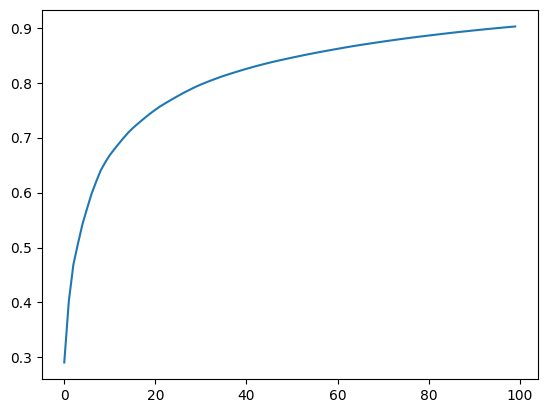

In [11]:
import matplotlib.pyplot as plt 

plt.plot(np.cumsum(pca.explained_variance_ratio_)[:500])